<a href="https://colab.research.google.com/github/Chris-car8/Challenge_telecomX/blob/main/Challenge_Telecomx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##   Challenge Telecomx para el programa de Alura Latam

In [29]:
import pandas as pd


## Extracción de Datos

In [30]:
datos = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json')

In [31]:
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Normalizando Datos

In [32]:
dict_columns = ['customer', 'phone', 'internet', 'account']

normalized_dfs = []

for col in dict_columns:
    normalized_col_df = pd.json_normalize(datos[col]).add_prefix(f'{col}_')
    normalized_dfs.append(normalized_col_df)

datos_cleaned = datos.drop(columns=dict_columns)

datos_2 = pd.concat([datos_cleaned] + normalized_dfs, axis=1)

In [33]:
datos_2.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [34]:
datos_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [35]:
datos_2.shape

(7267, 21)

## verificando valores nulos, duplicados y formatos

In [36]:
print(f".valores nulos : {datos_2['account_Charges.Monthly'].isnull().sum()}")

.valores nulos : 0


In [37]:
print(f".valores nulos : {datos_2['customer_SeniorCitizen'].isnull().sum()}")

.valores nulos : 0


In [38]:
if datos_2['customerID'].dtype=='object':
  print(f".valores duplicados : {datos_2['customerID'].duplicated().sum()}")

.valores duplicados : 0


In [39]:
columnas_data= datos_2.columns.to_list()
columnas_data

['customerID',
 'Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod',
 'account_Charges.Monthly',
 'account_Charges.Total']

In [40]:
columnas_nuevas = [
    'id_cliente',
    'abandono',
    'sexo',
    'adulto',
    'parejas',
    'dependiente',
    'antiguedad',
    'linea_tel',
    'otras_lineas',
    'internet',
    'seguridad_enlinea',
    'backup_enlinea',
    'proteccion_dispositivo',
    'soporte_tec',
    'tv_streaming',
    'peliculas_streaming',
    'tipo_contrato',
    'factura_fisica',
    'medio_pago',
    'pago_mensual',
    'pago_total'
]

In [41]:
columnas_data_dict = dict(zip(columnas_data, columnas_nuevas))
datos_2.rename(columns=columnas_data_dict, inplace=True)
datos_2.head()


,id_cliente,abandono,sexo,adulto,parejas,dependiente,antiguedad,linea_tel,otras_lineas,internet,...,backup_enlinea,proteccion_dispositivo,soporte_tec,tv_streaming,peliculas_streaming,tipo_contrato,factura_fisica,medio_pago,pago_mensual,pago_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [42]:
columnas_vacias = [
                    col for col in datos_2.columns
                    if datos_2[col].astype(str).str.strip().eq('').any()
]
columnas_vacias

['abandono', 'pago_total']

In [43]:
mascara = datos_2[columnas_vacias].astype(str).apply(lambda x: x.str.strip().eq('').all(), axis=1)
datos_2[mascara]

,id_cliente,abandono,sexo,adulto,parejas,dependiente,antiguedad,linea_tel,otras_lineas,internet,...,backup_enlinea,proteccion_dispositivo,soporte_tec,tv_streaming,peliculas_streaming,tipo_contrato,factura_fisica,medio_pago,pago_mensual,pago_total


In [44]:
pago_diario = datos_2['pago_mensual']/30
datos_2['pago_diario'] = pago_diario
datos_2.head()


,id_cliente,abandono,sexo,adulto,parejas,dependiente,antiguedad,linea_tel,otras_lineas,internet,...,proteccion_dispositivo,soporte_tec,tv_streaming,peliculas_streaming,tipo_contrato,factura_fisica,medio_pago,pago_mensual,pago_total,pago_diario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


## Pago Diario

In [45]:
pago_diario = datos_2[['sexo','internet','tv_streaming','peliculas_streaming','abandono','pago_diario']]
pago_diario.head()


,sexo,internet,tv_streaming,peliculas_streaming,abandono,pago_diario
0,Female,DSL,Yes,No,No,2.186667
1,Male,DSL,No,Yes,No,1.996667
2,Male,Fiber optic,No,No,Yes,2.463333
3,Male,Fiber optic,Yes,Yes,Yes,3.266667
4,Female,Fiber optic,Yes,No,Yes,2.796667


## Estandarización y trasformación de datos

In [46]:
mapping = {'Yes':1,'No':0, 'Female':0,'Male':1,'No internet service':0, '':0, 'No phone service':0}
columnas_binarias = ['sexo','tv_streaming','peliculas_streaming','linea_tel','abandono','parejas','dependiente','otras_lineas','proteccion_dispositivo','soporte_tec','factura_fisica']
datos_2.loc[:, columnas_binarias] = datos_2[columnas_binarias].replace(mapping).astype(int)
datos_2.head()

/tmp/ipython-input-3235345356.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_2.loc[:, columnas_binarias] = datos_2[columnas_binarias].replace(mapping).astype(int)


,id_cliente,abandono,sexo,adulto,parejas,dependiente,antiguedad,linea_tel,otras_lineas,internet,...,proteccion_dispositivo,soporte_tec,tv_streaming,peliculas_streaming,tipo_contrato,factura_fisica,medio_pago,pago_mensual,pago_total,pago_diario
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4,2.796667


In [47]:
columnas_eliminar = ['id_cliente','pago_mensual','pago_total']
datos_2.drop(columns=columnas_eliminar, inplace=True)

datos_2.head()

,abandono,sexo,adulto,parejas,dependiente,antiguedad,linea_tel,otras_lineas,internet,seguridad_enlinea,backup_enlinea,proteccion_dispositivo,soporte_tec,tv_streaming,peliculas_streaming,tipo_contrato,factura_fisica,medio_pago,pago_diario
0,0,0,0,1,1,9,1,0,DSL,No,Yes,0,1,1,0,One year,1,Mailed check,2.186667
1,0,1,0,0,0,9,1,1,DSL,No,No,0,0,0,1,Month-to-month,0,Mailed check,1.996667
2,1,1,0,0,0,4,1,0,Fiber optic,No,No,1,0,0,0,Month-to-month,1,Electronic check,2.463333
3,1,1,1,1,0,13,1,0,Fiber optic,No,Yes,1,0,1,1,Month-to-month,1,Electronic check,3.266667
4,1,0,1,1,0,3,1,0,Fiber optic,No,No,0,1,1,0,Month-to-month,1,Mailed check,2.796667


In [48]:
import matplotlib.pyplot as plt


In [49]:
import seaborn as sns

In [50]:
datos_2.nunique()

,0
abandono,2
sexo,2
adulto,2
parejas,2
dependiente,2
antiguedad,73
linea_tel,2
otras_lineas,2
internet,3
seguridad_enlinea,3


In [51]:
estadisticas_sexo = datos_2.groupby('sexo').agg({
    'abandono': ['sum', 'mean', 'count'],
    'adulto': ['sum', 'mean'],
    'antiguedad': ['sum', 'mean', 'median'],
    'pago_diario': ['sum', 'mean', 'median']
}).round(2)

estadisticas_sexo.head()

abandono                 adulto       antiguedad                \
          sum      mean count    sum  mean        sum   mean median   
sexo                                                                  
0         939  0.261414  3592    590  0.16     115674  32.20   29.0   
1         930  0.253061  3675    592  0.16     119388  32.49   29.0   

     pago_diario               
             sum  mean median  
sexo                           
0        7799.83  2.17   2.35  
1        7877.54  2.14   2.34

In [52]:
estadisticas_servicio = datos_2.groupby('internet').agg({
    'sexo': ['sum', 'mean','count'],
    'abandono': ['sum', 'mean', 'count'],
    'adulto': ['sum', 'mean'],
    'antiguedad': ['sum', 'mean', 'median'],
    'pago_diario': ['sum', 'mean', 'median']
}).round(2)

estadisticas_servicio.head()

sexo                 abandono                 adulto        \
              sum      mean count      sum      mean count    sum  mean   
internet                                                                  
DSL          1266  0.508842  2488      459  0.184486  2488    267  0.11   
Fiber optic  1600  0.500313  3198     1297  0.405566  3198    860  0.27   
No            809  0.511701  1581      113  0.071474  1581     55  0.03   

            antiguedad               pago_diario               
                   sum   mean median         sum  mean median  
internet                                                       
DSL              81361  32.70   29.0     4810.89  1.93   1.87  
Fiber optic     105289  32.92   30.0     9755.44  3.05   3.06  
No               48412  30.62   25.0     1111.03  0.70   0.67

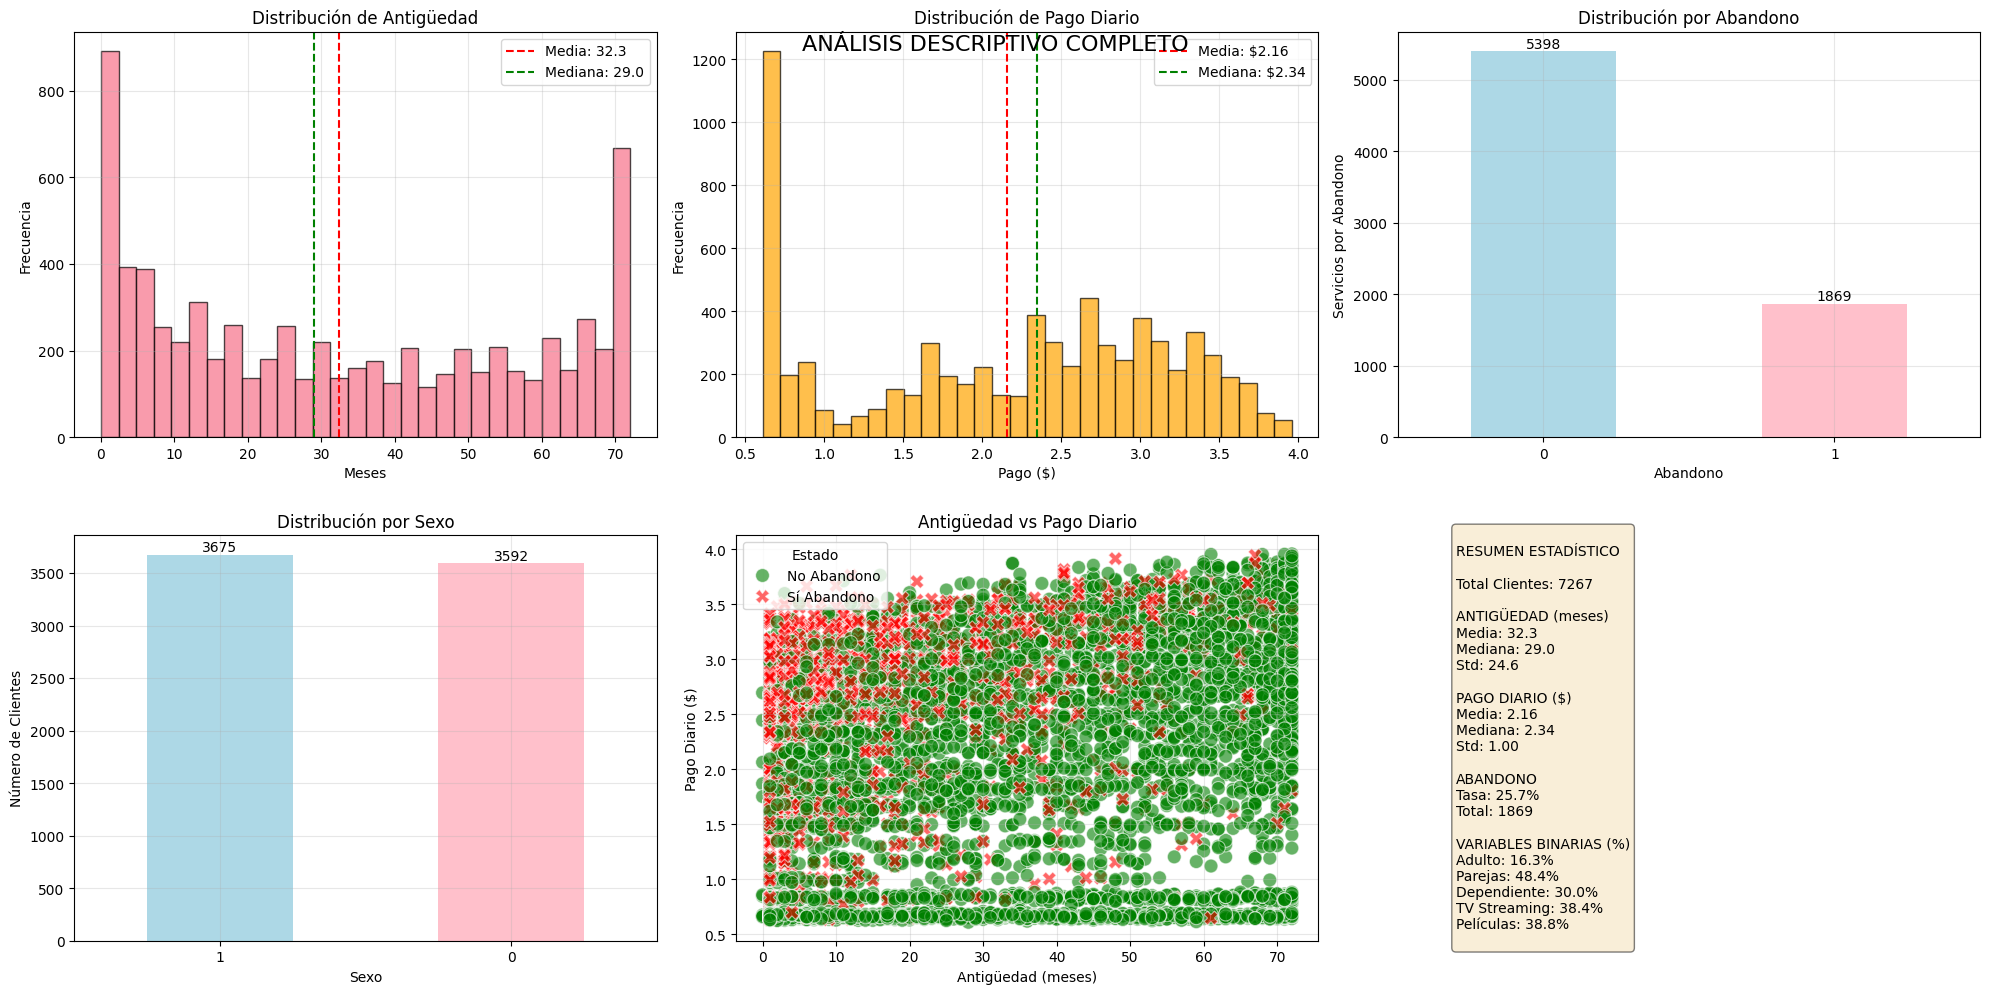

In [53]:

sns.set_palette("husl")
fig = plt.figure(figsize=(20, 15))


ax1 = plt.subplot(3, 3, 1)
datos_2['antiguedad'].hist(bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(datos_2['antiguedad'].mean(), color='red', linestyle='--', label=f'Media: {datos_2["antiguedad"].mean():.1f}')
ax1.axvline(datos_2['antiguedad'].median(), color='green', linestyle='--', label=f'Mediana: {datos_2["antiguedad"].median():.1f}')
ax1.set_title('Distribución de Antigüedad')
ax1.set_xlabel('Meses')
ax1.set_ylabel('Frecuencia')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 3, 2)
datos_2['pago_diario'].hist(bins=30, edgecolor='black', alpha=0.7, color='orange')
ax2.axvline(datos_2['pago_diario'].mean(), color='red', linestyle='--', label=f'Media: ${datos_2["pago_diario"].mean():.2f}')
ax2.axvline(datos_2['pago_diario'].median(), color='green', linestyle='--', label=f'Mediana: ${datos_2["pago_diario"].median():.2f}')
ax2.set_title('Distribución de Pago Diario')
ax2.set_xlabel('Pago ($)')
ax2.set_ylabel('Frecuencia')
ax2.legend()
ax2.grid(True, alpha=0.3)


ax3 = plt.subplot(3, 3, 3)
if 'abandono' in datos_2.columns:
    abandono_counts = datos_2['abandono'].value_counts()
    abandono_counts.plot(kind='bar', ax=ax3, color=['lightblue', 'pink'])
    ax3.set_title('Distribución por Abandono')
    ax3.set_xlabel('Abandono')
    ax3.set_ylabel('Servicios por Abandono')
    ax3.tick_params(axis='x', rotation=0)
    for i, v in enumerate(abandono_counts.values):
        ax3.text(i, v + 5, str(v), ha='center', va='bottom')
    ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 3, 4)
if 'sexo' in datos_2.columns:
    sexo_counts = datos_2['sexo'].value_counts()
    sexo_counts.plot(kind='bar', ax=ax4, color=['lightblue', 'pink'])
    ax4.set_title('Distribución por Sexo')
    ax4.set_xlabel('Sexo')
    ax4.set_ylabel('Número de Clientes')
    ax4.tick_params(axis='x', rotation=0)
    for i, v in enumerate(sexo_counts.values):
        ax4.text(i, v + 5, str(v), ha='center', va='bottom')
    ax4.grid(True, alpha=0.3)



ax5 = plt.subplot(3, 3, 5)


sns.scatterplot(data=datos_2,
                x='antiguedad',
                y='pago_diario',
                hue='abandono',
                style='abandono',
                palette={0: 'green', 1: 'red'},
                alpha=0.6,
                s=100,
                ax=ax5)

ax5.set_title('Antigüedad vs Pago Diario', fontsize=12)
ax5.set_xlabel('Antigüedad (meses)', fontsize=10)
ax5.set_ylabel('Pago Diario ($)', fontsize=10)
ax5.grid(True, alpha=0.3)

handles, labels = ax5.get_legend_handles_labels()
ax5.legend(handles, ['No Abandono', 'Sí Abandono'], title='Estado')


ax6 = plt.subplot(3, 3, 6)
ax6.axis('off')
resumen_texto = f"""
RESUMEN ESTADÍSTICO

Total Clientes: {len(datos_2)}

ANTIGÜEDAD (meses)
Media: {datos_2['antiguedad'].mean():.1f}
Mediana: {datos_2['antiguedad'].median():.1f}
Std: {datos_2['antiguedad'].std():.1f}

PAGO DIARIO ($)
Media: {datos_2['pago_diario'].mean():.2f}
Mediana: {datos_2['pago_diario'].median():.2f}
Std: {datos_2['pago_diario'].std():.2f}

ABANDONO
Tasa: {datos_2['abandono'].mean()*100:.1f}%
Total: {datos_2['abandono'].sum():.0f}

VARIABLES BINARIAS (%)
Adulto: {datos_2['adulto'].mean()*100:.1f}%
Parejas: {datos_2['parejas'].mean()*100:.1f}%
Dependiente: {datos_2['dependiente'].mean()*100:.1f}%
TV Streaming: {datos_2['tv_streaming'].mean()*100:.1f}%
Películas: {datos_2['peliculas_streaming'].mean()*100:.1f}%
"""
ax6.text(0.1, 0.5, resumen_texto, fontsize=10, verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)) # Changed ax5 to ax6

plt.suptitle('ANÁLISIS DESCRIPTIVO COMPLETO', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

## Informe

## Introducción

El informe se realiza con el fin de presentar los datos y el análisis de la Data Telecomx para el programa de Alura Latam, el reto trata de explicar la Data desde el Churn, analizando variables que afectan el abandono de los clientes.
Los primeros pasos será explorar la Data y tratar de entender los datos mostrados desde las librerías y los gráficos para tener una contextualización y llegar a realizar unas conclusiones acertadas.
También la explicación sirve para dar opciones de las estrategias a tomar por parte de la empresa con el fin de retener los clientes.


## Limpieza y Tratamiento de Datos

### Importar
Se identifico el tipo de archivo a leer, se importo la librería Pandas que es la que nos ayuda a leer los archivos, se realizo la lectura del archivo con la extensión JSON

## Limpieza y Trasformación
Para la trasformación y limpieza de los datos se uso los comando de Normalize, para ver los datos en un DataFrame, también se identificaron valores nullos, valores duplicados, como es su mayoría los datos tenia valores de tipo string se realizaron cambios por valores binarios, utilizando la técnica de mapeo por cada columna.
por otro lado, se analizo desde el comienzo las columnas encontrando que la columna que identifica al usuario no representaba valor y que esta no aportaba ningún análisis, se decidió eliminar con el fin de evitar ruido en la Data.


## Análisis Exploratorio de Datos

En nuestro primer análisis exploratorio de los datos encontramos que es de una empresa que presta servicios de internet y otros, como son películas online, tv streaming, que tiene una columna de deserción, tiempo de permanencia

##Distribución de antigüedad
En esta grafica observamos la distribución de antigüedad donde observamos la distribución se concentra entre los primeros meses y los últimos y también tenemos una media de 32.3 con una mediana de 29, esto quiere decir que en la duración de 0 a 12 mese es alta y va relacionado con el precio diario.


##Distribución de pago diario
La grafica de distribución de pago diario nos muestra la composición en dólares el pago de los clientes, donde la media es 2.16 dólares, también observamos la mayor concentración hasta los 2.34 dólares.


##Distribución de abandono (Churn)
La tasa de abandono es del 25.7 %, mostrando un alto abandono de los clientes de la empresa de telecomunicaciones, esta es la variable para analizar, debido a las cifras analizada, por eso a continuación se realizo una grafica donde se analiza el tiempo de permanencia, el pago diario y el abandono.


##Antigüedad vs el pago diario
Para este análisis mostramos que el abandono se encuentra en los primeros meses entre los 0 a 20 meses, donde el pago a diario entre 2.5 y 3.5 dólares diario esta influido para el abandono de los clientes.
También encontramos que a partir de los 40 meses la tasa de abandono es muy baja, eso ratifica la fidelidad de los clientes hacia la empresa, también podemos deducir que entre mas bajo sea el precio diario es menos factible que se tenga abandono por parte del cliente.


#Estrategias
La empresa de telecomunicaciones puede implementar varias estrategias como son:
•	Reforzar la comunicación hacia el cliente entre los primeros 10 meses.
•	Reducción del precio diario, mostrando promociones para los clientes en los 10 meses.
•	También para las parejas que son un 48.4 %, se debe hacer una campaña especifica donde se puede incrementar el pago diario para compensar con las promociones ofrecidas.
Como vemos en análisis de datos es muy importante por que nos muestra la realidad de una empresa y también los problemas que se pueden identificar. Como se identifican problemas podemos encontrar soluciones a estos.
